In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from lightgbm import LGBMRegressor

In [2]:
import shap

# 데이터 불러오기

In [3]:
housing = fetch_california_housing()

# 입력 변수(feature)
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# 타겟 변수(집값)
y = pd.Series(housing.target, name='target')

In [4]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: target, Length: 20640, dtype: float64

In [6]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
# 모델 생성 및 학습
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000363 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [8]:
# SHAP Explainer 생성
explainer = shap.TreeExplainer(model)

# shap 값 계산 (테스트 데이터 기준)
shap_values = explainer.shap_values(X_test)    # 각 feature가 예측에 얼마나 기여했는지 score 계산


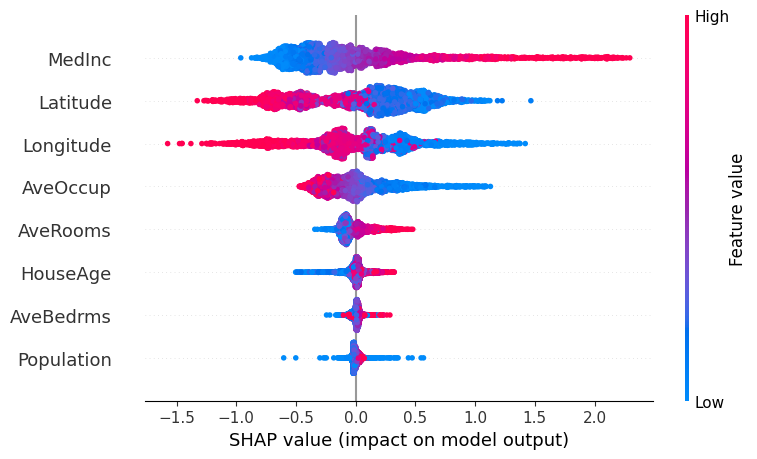

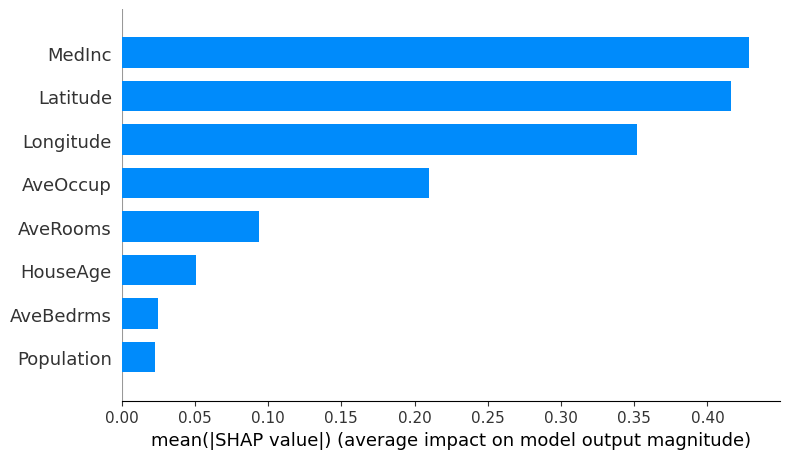

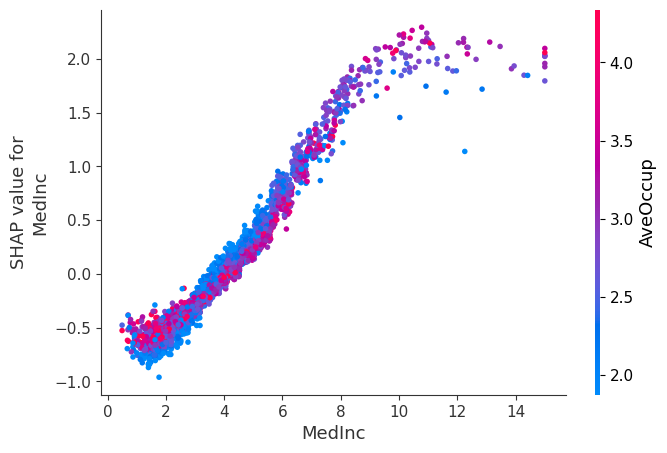

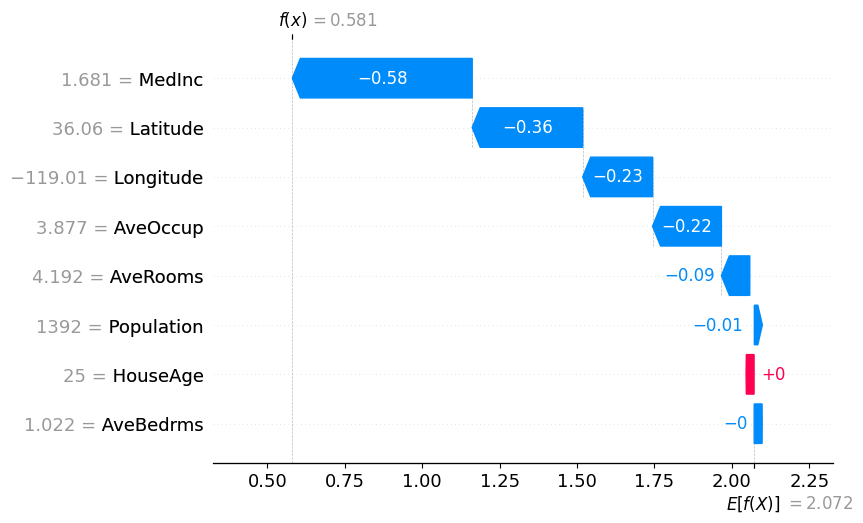


[SHAP 값 샘플]
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0 -0.580755  0.000887 -0.091632  -0.000387   -0.014700 -0.222255 -0.356787   
1 -0.491580  0.025925 -0.105208   0.053759    0.006504  0.003098 -0.472470   
2  0.038094  0.309970 -0.044298   0.054821   -0.020946  0.784144  0.244839   
3  0.515880 -0.017496  0.030108  -0.010587    0.000954 -0.339485  0.149926   
4 -0.096139  0.029217 -0.024359   0.007217   -0.008561  0.077057 -0.035779   

   Longitude  
0  -0.225686  
1  -0.192753  
2   1.419950  
3   0.001678  
4   0.496815  


In [10]:
%matplotlib inline

# 영향도 시각화
shap.summary_plot(shap_values, X_test)   # 점 위치 : 영향 방향(+/-), 색 : feature 값 크기
 
# shap bar plot (방향성)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# shap dependence plot
shap.dependence_plot("MedInc", shap_values, X_test)

# shap waterfall plot
sample_index = 0

# 개별 샘플 shap 값
shap.initjs()  # 시각화 초기화

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X.columns
    )
)

# Force plot (interactive)

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

# shap 값 직접 확인
shap_df = pd.DataFrame(shap_values, columns=X.columns)

print("\n[SHAP 값 샘플]")
print(shap_df.head())


